# Telco Customer Churn: Who Should the Retention Team Call First?

**Business question:** customers are leaving. The retention team has a limited budget for offers.
**Who should they contact, and how much revenue could that save?**

Accuracy alone doesn't answer that, so this notebook goes one step further:
1. Build a model that predicts each customer's chance of leaving
2. Turn those predictions into **expected revenue at risk** per customer
3. Find the **customer segments** to prioritise
4. Estimate **revenue saved** by a targeted campaign, compared with random targeting

Data: IBM Telco Customer Churn (7,043 customers, 21 columns).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

pd.set_option('display.float_format', '{:,.3f}'.format)
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8983'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .25, 'figure.dpi': 110})
FIG = '../figures/'

## 1. Load and clean

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print('Overall churn rate:', (df.Churn == 'Yes').mean().round(3))

# TotalCharges is text, and 11 new customers (tenure = 0) have a blank value
print('Blank TotalCharges:', (df.TotalCharges.str.strip() == '').sum())
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce').fillna(0)
df['churn'] = (df.Churn == 'Yes').astype(int)
df['tenure_group'] = pd.cut(df.tenure, [-1, 12, 24, 48, 72],
                            labels=['0-12 mo', '13-24 mo', '25-48 mo', '49-72 mo'])

(7043, 21)
Overall churn rate: 0.265
Blank TotalCharges: 11


## 2. What drives churn?

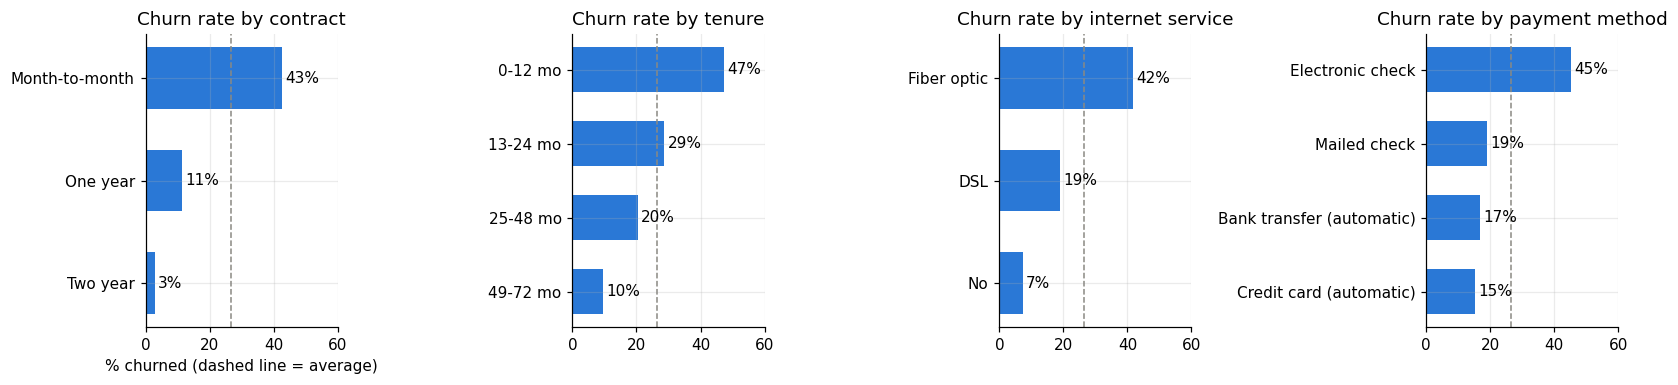

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=True)
titles = {'Contract': 'contract', 'tenure_group': 'tenure', 'InternetService': 'internet service', 'PaymentMethod': 'payment method'}
for ax, col in zip(axes, titles):
    r = df.groupby(col, observed=True).churn.mean().sort_values() * 100
    ax.barh(r.index.astype(str), r.values, color=BLUE, height=.6)
    for i, v in enumerate(r.values): ax.text(v + 1, i, f'{v:.0f}%', va='center')
    ax.set_title(f'Churn rate by {titles[col]}'); ax.set_xlim(0, 60)
    ax.axvline(df.churn.mean()*100, color=GREY, ls='--', lw=1)
axes[0].set_xlabel('% churned (dashed line = average)')
plt.tight_layout(); plt.savefig(FIG + 'churn_drivers.png', bbox_inches='tight'); plt.show()

**Takeaways:** month-to-month contracts (43% churn), customers in their first year (47%), fibre-optic internet users (42%) and electronic-check payers (45%) leave far more often than average (27%).

## 3. Predict churn

Two models are compared with 5-fold cross-validation:
- **Logistic regression:** simple and easy to explain
- **Gradient boosting:** more flexible

Cross-validation gives an honest, out-of-sample churn probability for **every** customer, which is used later for the revenue estimate.

In [4]:
# TotalCharges is left out: it's roughly tenure x monthly charge, so it would duplicate those two
X = df.drop(columns=['customerID', 'Churn', 'churn', 'tenure_group', 'TotalCharges'])
y = df.churn
cat = [c for c in X.columns if c not in ['tenure', 'MonthlyCharges', 'SeniorCitizen']]
num = ['tenure', 'MonthlyCharges', 'SeniorCitizen']

prep = ColumnTransformer([('num', StandardScaler(), num),
                          ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cat)])
models = {
    'Logistic regression': Pipeline([('prep', prep), ('m', LogisticRegression(max_iter=1000, C=0.5))]),
    'Gradient boosting':   Pipeline([('prep', prep), ('m', HistGradientBoostingClassifier(
                                max_depth=3, learning_rate=0.05, max_iter=200, random_state=42))]),
}
cv = StratifiedKFold(5, shuffle=True, random_state=42)
scores, oof = {}, {}
for name, m in models.items():
    oof[name] = cross_val_predict(m, X, y, cv=cv, method='predict_proba')[:, 1]
    scores[name] = {'ROC-AUC': roc_auc_score(y, oof[name]),
                    'PR-AUC': average_precision_score(y, oof[name])}
pd.DataFrame(scores).T

,ROC-AUC,PR-AUC
Logistic regression,0.843,0.651
Gradient boosting,0.845,0.656


In [5]:
# Use the better model; logistic regression wins ties because it's easier to explain
best = max(scores, key=lambda k: scores[k]['ROC-AUC'] + (0.002 if k.startswith('Logistic') else 0))
df['churn_prob'] = oof[best]
print('Chosen model:', best)

# Accuracy-style report at a 0.5 cut-off, for reference only
print(classification_report(y, (df.churn_prob > .5).astype(int), target_names=['Stay', 'Churn']))

Chosen model: Logistic regression
              precision    recall  f1-score   support

        Stay       0.84      0.90      0.87      5174
       Churn       0.65      0.54      0.59      1869

    accuracy                           0.80      7043
   macro avg       0.75      0.72      0.73      7043
weighted avg       0.79      0.80      0.80      7043



In [6]:
# Top 10 of customers ranked by risk: how many real churners are in there?
df['risk_decile'] = pd.qcut(df.churn_prob.rank(method='first', ascending=False), 10, labels=range(1, 11))
dec = df.groupby('risk_decile', observed=True).agg(customers=('churn','size'), churn_rate=('churn','mean'))
dec['lift_vs_avg'] = dec.churn_rate / df.churn.mean()
dec['cum_share_of_churners'] = df.groupby('risk_decile', observed=True).churn.sum().cumsum() / df.churn.sum()
dec

,customers,churn_rate,lift_vs_avg,cum_share_of_churners
risk_decile,,,,
1,705,0.752,2.833,0.284
2,704,0.599,2.259,0.509
3,704,0.402,1.515,0.661
4,704,0.330,1.242,0.785
5,705,0.223,0.839,0.869
6,704,0.173,0.653,0.934
7,704,0.088,0.332,0.967
8,704,0.048,0.182,0.986
9,704,0.026,0.096,0.995


The riskiest 10% of customers churn at about 3x the average rate, and the top 30% contain roughly two-thirds of all churners.
**The model ranks customers well**, and ranking is what the retention team needs.

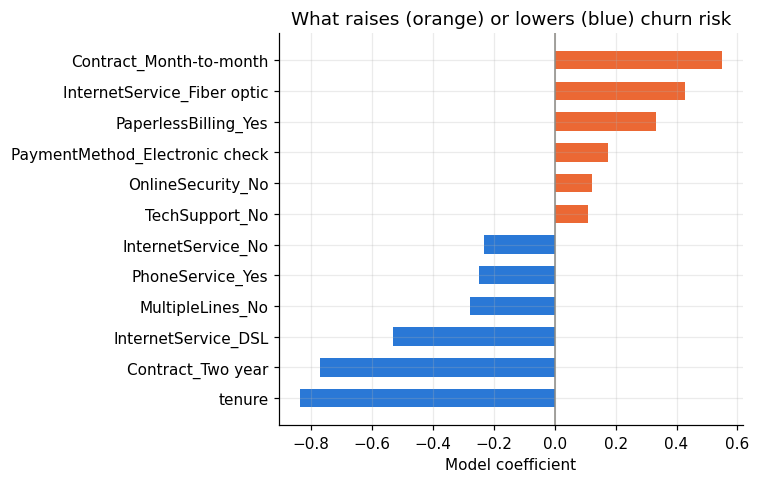

In [7]:
# What pushes risk up or down? (logistic regression coefficients)
lr = models['Logistic regression'].fit(X, y)
names = lr.named_steps['prep'].get_feature_names_out()
coef = pd.Series(lr.named_steps['m'].coef_[0], index=names).sort_values()
coef.index = coef.index.str.replace('cat__|num__', '', regex=True)
top = pd.concat([coef.head(6), coef.tail(6)])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top.index, top.values, color=[BLUE if v < 0 else ORANGE for v in top.values], height=.6)
ax.axvline(0, color=GREY, lw=1)
ax.set_title('What raises (orange) or lowers (blue) churn risk'); ax.set_xlabel('Model coefficient')
plt.tight_layout(); plt.savefig(FIG + 'risk_factors.png', bbox_inches='tight'); plt.show()

## 4. From churn probability to revenue at risk

**Expected annual revenue at risk** per customer = churn probability × monthly charge × 12.

A customer with a 60% risk paying $100/month is a bigger priority than one with a 70% risk paying $20/month.

In [8]:
df['annual_value'] = df.MonthlyCharges * 12
df['revenue_at_risk'] = df.churn_prob * df.annual_value
print(f"Total expected annual revenue at risk: ${df.revenue_at_risk.sum():,.0f}")
print(f"Actual annual revenue of customers who churned: ${df.loc[df.churn==1,'annual_value'].sum():,.0f}")

Total expected annual revenue at risk: $1,671,526
Actual annual revenue of customers who churned: $1,669,570


## 5. Which segments should the retention team prioritise?

Segments are simple enough for the retention team to act on: **contract type × tenure × internet service**.
They are ranked by total revenue at risk.

In [9]:
seg = (df.groupby(['Contract', 'tenure_group', 'InternetService'], observed=True)
         .agg(customers=('churn', 'size'),
              avg_churn_prob=('churn_prob', 'mean'),
              actual_churn_rate=('churn', 'mean'),
              avg_monthly_bill=('MonthlyCharges', 'mean'),
              revenue_at_risk=('revenue_at_risk', 'sum'))
         .query('customers >= 50')
         .sort_values('revenue_at_risk', ascending=False))
seg['share_of_total_risk'] = seg.revenue_at_risk / df.revenue_at_risk.sum()
seg['cum_share'] = seg.share_of_total_risk.cumsum()
seg.head(8)

customers  avg_churn_prob  \
Contract       tenure_group InternetService                              
Month-to-month 0-12 mo      Fiber optic            916           0.677   
               13-24 mo     Fiber optic            425           0.579   
               25-48 mo     Fiber optic            521           0.451   
               0-12 mo      DSL                    690           0.391   
               49-72 mo     Fiber optic            266           0.278   
One year       49-72 mo     Fiber optic            355           0.140   
               25-48 mo     Fiber optic            154           0.240   
Month-to-month 13-24 mo     DSL                    232           0.296   

                                             actual_churn_rate  \
Contract       tenure_group InternetService                      
Month-to-month 0-12 mo      Fiber optic                  0.702   
               13-24 mo     Fiber optic                  0.506   
               25-48 mo     Fiber optic                  0.434   
               0-12 mo      DSL                          0.425   
               49-72 mo     Fiber optic                  0.293   
One year       49-72 mo     Fiber optic                  0.189   
               25-48 mo     Fiber optic                  0.201   
Month-to-month 13-24 mo     DSL                          0.237   

                                             avg_monthly_bill  \
Contract       tenure_group InternetService                     
Month-to-month 0-12 mo      Fiber optic                82.078   
               13-24 mo     Fiber optic                87.541   
               25-48 mo     Fiber optic                91.239   
               0-12 mo      DSL                        47.884   
               49-72 mo     Fiber optic                94.953   
One year       49-72 mo     Fiber optic               100.489   
               25-48 mo     Fiber optic                96.044   
Month-to-month 13-24 mo     DSL                        52.681   

                                             revenue_at_risk  \
Contract       tenure_group InternetService                    
Month-to-month 0-12 mo      Fiber optic          614,567.433   
               13-24 mo     Fiber optic          260,450.009   
               25-48 mo     Fiber optic          260,110.258   
               0-12 mo      DSL                  151,662.873   
               49-72 mo     Fiber optic           85,187.209   
One year       49-72 mo     Fiber optic           60,121.651   
               25-48 mo     Fiber optic           42,820.565   
Month-to-month 13-24 mo     DSL                   42,189.739   

                                             share_of_total_risk  cum_share  
Contract       tenure_group InternetService                                  
Month-to-month 0-12 mo      Fiber optic                    0.368      0.368  
               13-24 mo     Fiber optic                    0.156      0.523  
               25-48 mo     Fiber optic                    0.156      0.679  
               0-12 mo      DSL                            0.091      0.770  
               49-72 mo     Fiber optic                    0.051      0.821  
One year       49-72 mo     Fiber optic                    0.036      0.857  
               25-48 mo     Fiber optic                    0.026      0.882  
Month-to-month 13-24 mo     DSL                            0.025      0.908

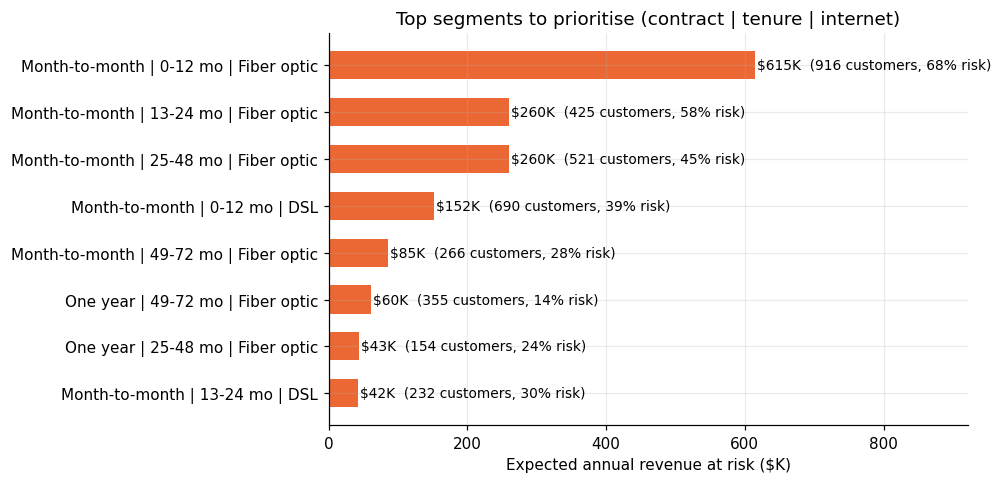

In [10]:
top8 = seg.head(8).iloc[::-1]
labels = [f'{c} | {t} | {i}' for c, t, i in top8.index]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(labels, top8.revenue_at_risk / 1000, color=ORANGE, height=.6)
for i, (v, n, p) in enumerate(zip(top8.revenue_at_risk, top8.customers, top8.avg_churn_prob)):
    ax.text(v/1000 + 3, i, f'${v/1000:,.0f}K  ({n} customers, {p:.0%} risk)', va='center', fontsize=9)
ax.set_xlabel('Expected annual revenue at risk ($K)')
ax.set_title('Top segments to prioritise (contract | tenure | internet)')
ax.set_xlim(0, top8.revenue_at_risk.max()/1000 * 1.5)
plt.tight_layout(); plt.savefig(FIG + 'priority_segments.png', bbox_inches='tight'); plt.show()

## 6. How much revenue could a targeted campaign save?

**Assumptions** (stated so they can be changed):
| Assumption | Value | Why |
|---|---|---|
| Cost of a retention offer | **$100** per customer contacted | e.g. a discount or credit |
| Offer success rate | **30%** of would-be churners are saved | a common industry planning figure |
| Value of a saved customer | **12 months** of their monthly bill | a one-year view |

Customers who weren't going to leave still cost $100 if contacted, so contacting everyone wastes money.
The campaign contacts the customers with the highest **revenue at risk** first, and the results are compared with random selection.
Real churn outcomes are used, so the estimate isn't based on the model grading itself.

In [11]:
OFFER_COST, SAVE_RATE = 100, 0.30

def campaign(order, cost=OFFER_COST, save=SAVE_RATE):
    d = df.loc[order]
    saved = (d.churn * d.annual_value * save).cumsum().to_numpy()
    spent = cost * np.arange(1, len(d) + 1)
    return saved - spent

model_order = df.revenue_at_risk.sort_values(ascending=False).index
rand_order = df.sample(frac=1, random_state=0).index
net_model, net_rand = campaign(model_order), campaign(rand_order)
pct = np.arange(1, len(df) + 1) / len(df) * 100

k = net_model.argmax()
print(f'Best plan: contact the top {k+1:,} customers ({pct[k]:.0f}% of base)')
print(f'  Net revenue saved (model-targeted): ${net_model[k]:,.0f}')
print(f'  Same number contacted at random:   ${net_rand[k]:,.0f}')
print(f'  Contact everyone:                   ${net_model[-1]:,.0f}')

Best plan: contact the top 1,773 customers (25% of base)
  Net revenue saved (model-targeted): $154,856
  Same number contacted at random:   $-52,439
  Contact everyone:                   $-203,429


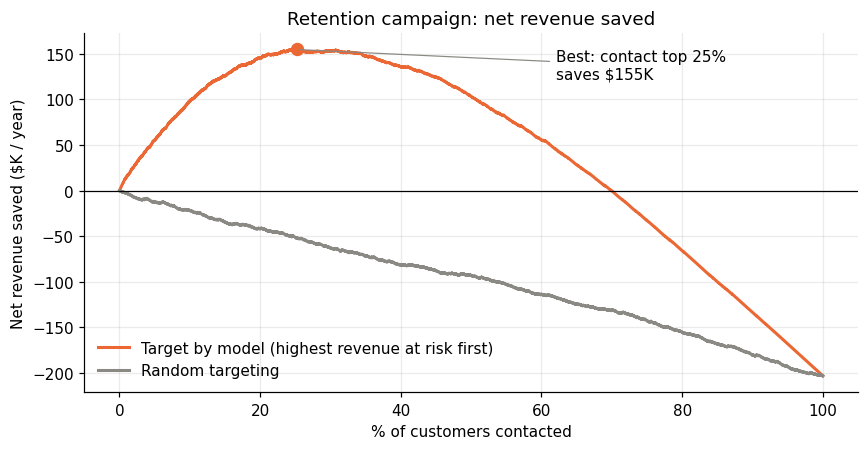

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(pct, net_model / 1000, color=ORANGE, lw=2, label='Target by model (highest revenue at risk first)')
ax.plot(pct, net_rand / 1000, color=GREY, lw=2, label='Random targeting')
ax.axhline(0, color='black', lw=.8)
ax.scatter(pct[k], net_model[k]/1000, s=60, color=ORANGE, zorder=3)
ax.annotate(f'Best: contact top {pct[k]:.0f}%\nsaves ${net_model[k]/1000:,.0f}K',
            (pct[k], net_model[k]/1000), xytext=(62, net_model[k]/1000), va='top',
            arrowprops=dict(arrowstyle='-', color=GREY, lw=.8))
ax.set_xlabel('% of customers contacted'); ax.set_ylabel('Net revenue saved ($K / year)')
ax.set_title('Retention campaign: net revenue saved')
ax.legend(frameon=False, loc='lower left')
plt.tight_layout(); plt.savefig(FIG + 'revenue_saved.png', bbox_inches='tight'); plt.show()

In [13]:
# Sensitivity: how does the answer change if the offer works better or worse?
rows = []
for save in [0.15, 0.30, 0.45]:
    for cost in [50, 100, 150]:
        n = campaign(model_order, cost, save)
        rows.append({'save_rate': f'{save:.0%}', 'offer_cost': f'${cost}',
                     'best_%_to_contact': round((n.argmax()+1)/len(df)*100),
                     'net_saved_$': round(n.max())})
pd.DataFrame(rows).pivot(index='save_rate', columns='offer_cost', values='net_saved_$')[['$50', '$100', '$150']]

offer_cost,$50,$100,$150
save_rate,,,
15%,77428,14162,1011
30%,283551,154856,76923
45%,509077,348191,232284


## 7. Recommendations for the retention team

1. **Start with month-to-month customers in their first year**, especially fibre-optic users. They make up the largest share of revenue at risk.
2. **Offer contract upgrades.** One- and two-year contracts churn at 11% and 3%, compared with 43% for month-to-month.
3. **Push automatic payment.** Electronic-check payers churn most, and switching them is cheap.
4. **Don't contact everyone.** Contacting the top ~25% by revenue at risk saves the most money. Beyond that, offers go to customers who would have stayed anyway.
5. **Test the offer before rolling it out.** The savings depend on the 30% success rate, so an A/B test of the offer on the top segment would confirm it.